In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

In [2]:
train_csv = pd.read_csv("data/train.csv")
oil_csv = pd.read_csv("data/oil.csv")

In [3]:
oil_csv['dcoilwtico'].values

array([  nan, 93.14, 92.97, ..., 46.46, 45.96, 47.26], shape=(1218,))

In [4]:
oil_csv['dcoilwtico'] = oil_csv['dcoilwtico'].ffill()
oil_csv['dcoilwtico'] = oil_csv['dcoilwtico'].bfill()

In [5]:
oil_csv['dcoilwtico'].isna().sum()

np.int64(0)

In [6]:
oil_csv['dcoilwtico']

0       93.14
1       93.14
2       92.97
3       93.12
4       93.20
        ...  
1213    47.65
1214    46.40
1215    46.46
1216    45.96
1217    47.26
Name: dcoilwtico, Length: 1218, dtype: float64

In [7]:
oil_prices = []
for index,val in enumerate(range(len(oil_csv))):
    date = oil_csv.iloc[index,0]
    oil_price = oil_csv.iloc[index,1]
    for index,v in enumerate(range(len(oil_csv))):
        train_date = train_csv.iloc[index,1]
        if train_date == date:
            oil_prices.append(oil_price)

In [8]:
train_csv = train_csv.merge(oil_csv, on='date', how='left')

In [9]:
stores_csv = pd.read_csv("data/stores.csv")

In [10]:
train_csv = train_csv.merge(stores_csv,on="store_nbr", how="left")

In [11]:
train_csv

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,93.14,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.000,0,93.14,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.000,0,93.14,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.000,0,93.14,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.000,0,93.14,Quito,Pichincha,D,13
...,...,...,...,...,...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0,47.57,Quito,Pichincha,B,6
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,47.57,Quito,Pichincha,B,6
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148,47.57,Quito,Pichincha,B,6
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,47.57,Quito,Pichincha,B,6


In [12]:
transactions_csv = pd.read_csv("data/transactions.csv")

In [13]:
train_csv.head(10)

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,93.14,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,93.14,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,93.14,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,93.14,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,93.14,Quito,Pichincha,D,13
5,5,2013-01-01,1,BREAD/BAKERY,0.0,0,93.14,Quito,Pichincha,D,13
6,6,2013-01-01,1,CELEBRATION,0.0,0,93.14,Quito,Pichincha,D,13
7,7,2013-01-01,1,CLEANING,0.0,0,93.14,Quito,Pichincha,D,13
8,8,2013-01-01,1,DAIRY,0.0,0,93.14,Quito,Pichincha,D,13
9,9,2013-01-01,1,DELI,0.0,0,93.14,Quito,Pichincha,D,13


In [14]:
holiday_csv = pd.read_csv("data/holidays_events.csv")
national_holidays = holiday_csv[holiday_csv["locale"] == "National"]

In [15]:
national_holidays["type"].value_counts()

type
Holiday       60
Event         56
Additional    40
Transfer       8
Bridge         5
Work Day       5
Name: count, dtype: int64

In [16]:
national_holidays.isna().sum()

date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64

In [17]:
train_csv = train_csv.merge(national_holidays,on="date",how="left")

In [18]:
train_csv.head(5)

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,city,state,type_x,cluster,type_y,locale,locale_name,description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,93.14,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False
1,1,2013-01-01,1,BABY CARE,0.0,0,93.14,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False
2,2,2013-01-01,1,BEAUTY,0.0,0,93.14,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False
3,3,2013-01-01,1,BEVERAGES,0.0,0,93.14,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False
4,4,2013-01-01,1,BOOKS,0.0,0,93.14,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False


In [19]:
train_csv.isna().sum()

id                   0
date                 0
store_nbr            0
family               0
sales                0
onpromotion          0
dcoilwtico      862488
city                 0
state                0
type_x               0
cluster              0
type_y         2746062
locale         2746062
locale_name    2746062
description    2746062
transferred    2746062
dtype: int64

In [20]:
holiday_csv["locale"].value_counts()

locale
National    174
Local       152
Regional     24
Name: count, dtype: int64

In [21]:
regional_holidays = holiday_csv[holiday_csv['locale'] == 'Regional'][['date', 'locale_name', 'type']]
regional_holidays = regional_holidays.rename(columns={'type': 'regional_holiday_type'})
train_csv = train_csv.merge(regional_holidays, left_on=['date', 'state'], right_on=['date', 'locale_name'], how='left')

local_holidays = holiday_csv[holiday_csv['locale'] == 'Local'][['date', 'locale_name', 'type']]
local_holidays = local_holidays.rename(columns={'type': 'local_holiday_type'})
train_csv = train_csv.merge(local_holidays, left_on=['date', 'city'], right_on=['date', 'locale_name'], how='left')

In [22]:
train_csv.isna().sum()

id                             0
date                           0
store_nbr                      0
family                         0
sales                          0
onpromotion                    0
dcoilwtico                862752
city                           0
state                          0
type_x                         0
cluster                        0
type_y                   2746326
locale                   2746326
locale_name_x            2746326
description              2746326
transferred              2746326
locale_name_y            3007257
regional_holiday_type    3007257
locale_name              2995773
local_holiday_type       2995773
dtype: int64

In [23]:
transactions_csv = pd.read_csv("data/transactions.csv")
train_csv = train_csv.merge(transactions_csv, on=['date', 'store_nbr'], how='left')

In [24]:
train_csv = train_csv.drop(columns=['locale_name_x', 'locale_name_y'])
train_csv = train_csv.rename(columns={'type_x': 'store_type', 'type_y': 'national_holiday_type'})

In [25]:
train_csv['national_holiday_type'] = train_csv['national_holiday_type'].fillna('None')
train_csv['regional_holiday_type'] = train_csv['regional_holiday_type'].fillna('None')
train_csv['local_holiday_type'] = train_csv['local_holiday_type'].fillna('None')

In [26]:
train_csv['is_holiday'] = (train_csv['national_holiday_type'] != 'None').astype(int)

In [27]:
train_csv['dcoilwtico'] = train_csv['dcoilwtico'].interpolate(method='linear')

<Axes: xlabel='date'>

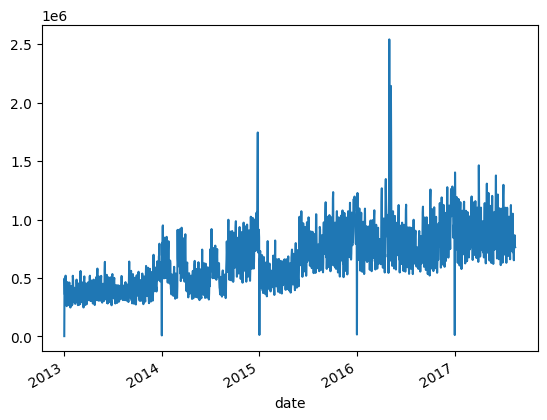

In [28]:
train_csv['date'] = pd.to_datetime(train_csv['date'])
train_csv.groupby('date')['sales'].sum().plot()